# PCA Final Project
Sahiba Kaur & Tanay Mishra

# Creating All Necessary Functions

In [ ]:
#implementing PCA based on Pr. Pavel and youtube
import numpy as np

#all methods are according to notes page 206-218:
def do_sortof_svd(A):
  #first need to get A transpose A
  AT = np.transpose(A)
  ATA = AT @ A
  #need to find eigenvalues and eigenvectors
  eigenvalues, eigenvectors = np.linalg.eigh(ATA) #eigh sorts in ascending order
  #need to flip the order of these for both eigenvectors and eigenvalues

  reverse_order = np.argsort(eigenvalues)[::-1]
  #to apply reverse order:
  eigenvalues = eigenvalues[reverse_order]
  eigenvectors = eigenvectors[:, reverse_order] #this should be equal to V in svd U(Sigma)V^t
  # now both go from Largest to Smallest eigenvalues and corresponding eigenvectors

  sqrt_eigenvalues = np.sqrt(eigenvalues) #we dont need this in a matrix since we only need the values

  #U is found page 181 lecture notes but basically u_i = (A*v_i)/o_i where o_i is sqrt(lambda_i)
  U = A @ eigenvectors
  for i in range(len(sqrt_eigenvalues)):
      U[:, i] /= sqrt_eigenvalues[i]


  # these are U, Sigma, and V^T
  return U, sqrt_eigenvalues, np.transpose(eigenvectors)

def center(X):
  #centering done by following page 207 of lecture notes
  m = X.shape[0] #this gets the number of data points from the matrix X
  mean_vector = (1/m) * np.sum(X, axis=0) #should sum cols
  centered_X = X - mean_vector
  return centered_X, mean_vector

def pca_via_svd(X, k):
  #here k is the number of best fit things so we can do the error percent stuff maybe

  centered_X, mean_vector = center(X)
  U, values, VT = do_sortof_svd(centered_X)

  k_components = VT[:k]
  projected_X = centered_X @ np.transpose(k_components) #projects data onto new k space
  sigma_squared = (values[:k]**2) #this gets the first k singular values and squares them

  return projected_X, sigma_squared, k_components, VT


def pca_via_covariance(X, k):
  m_data, n_features = X.shape
  centered_X, mean_vector = center(X)
  #this below is the sample covariance matrix page 208
  S = (1 / (m_data - 1)) * (centered_X.T @ centered_X)

  #steps below are same as some of the svd stuff
  eigenvalues, eigenvectors = np.linalg.eigh(S)
  reverse_order = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[reverse_order]
  eigenvectors = eigenvectors[:, reverse_order]

  k_components = eigenvectors[:, :k].T

  projected_X = centered_X @ k_components.T

  explained_variance = eigenvalues[:k]

  return projected_X, explained_variance, k_components



# Using the PCA Functions

Getting data from sklearn diabetes dataset \
There are 10 features, named in feature_names \
Printing out important data such as
*   Eigenvalues of the sample covariance matrix (variance along given direction)
*   The first 3 principal axes in terms of the original variables
*   The variance given each k value (number of components)



In [ ]:
import matplotlib.pyplot as plt

import pandas as pd


from sklearn import datasets
diabetes = datasets.load_diabetes()
X = diabetes.data


m_data, n_features = X.shape
feature_names = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]

projected, variances, k_components, V_meas = pca_via_svd(X, 10)
centered_X, mean_vector = center(X)

eigenvalues = (variances) / (m_data - 1)
for i, lam in enumerate(eigenvalues):
    print(f"  λ_{i} = {lam}")


total_variance = np.sum(variances)
var_ratio = variances / total_variance
percent_variances = np.cumsum(var_ratio)

print("\n")
print("="*50)

print("\nFirst principal axis (v₁):")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}: {V_meas[i, 0]:8.5f}")

print("\nSecond principal axis (v₂):")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}: {V_meas[i, 1]:8.5f}")

print("\nThird principal axis (v₃):")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}: {V_meas[i, 2]:8.5f}")

print("\n")
print("="*50)
print("\n")


U, eigen, VT = do_sortof_svd(X)

for i in range(1, 11):
  projected, variances, k_components, VT = pca_via_svd(X, i)
  i_variance = np.sum(variances)
  # print(variances)
  i_ratio = i_variance / total_variance
  print(f"variance with {i} components: {i_ratio*100} %")

print("\n")

r_m = len(eigen)



  λ_0 = 0.009125194444790893
  λ_1 = 0.003383944847162571
  λ_2 = 0.0027346173676303883
  λ_3 = 0.0021666131593290686
  λ_4 = 0.0015015451049119608
  λ_5 = 0.0013667053868937106
  λ_6 = 0.0012167021594543727
  λ_7 = 0.000983405978153255
  λ_8 = 0.00017759642734940795
  λ_9 = 1.941208577563031e-05



First principal axis (v₁):
  age         : -0.21643
  sex         : -0.04437
  bmi         : -0.49467
  bp          :  0.41401
  s1          : -0.68688
  s2          :  0.22582
  s3          :  0.10953
  s4          : -0.01494
  s5          : -0.00810
  s6          : -0.00326

Second principal axis (v₂):
  age         : -0.18697
  sex         :  0.38655
  bmi         :  0.10686
  bp          :  0.67986
  s1          :  0.37346
  s2          : -0.04171
  s3          :  0.06762
  s4          : -0.44293
  s5          :  0.00211
  s6          : -0.00366

Third principal axis (v₃):
  age         : -0.30316
  sex         :  0.15628
  bmi         : -0.16753
  bp          : -0.49982
  s1          :

# Plotting the Diabetes Data



1.   Variance Explained by Each Principal Axis
2.   Scree plot showing variance % for each k components
3.   Projecting the data onto R2 with k = 2

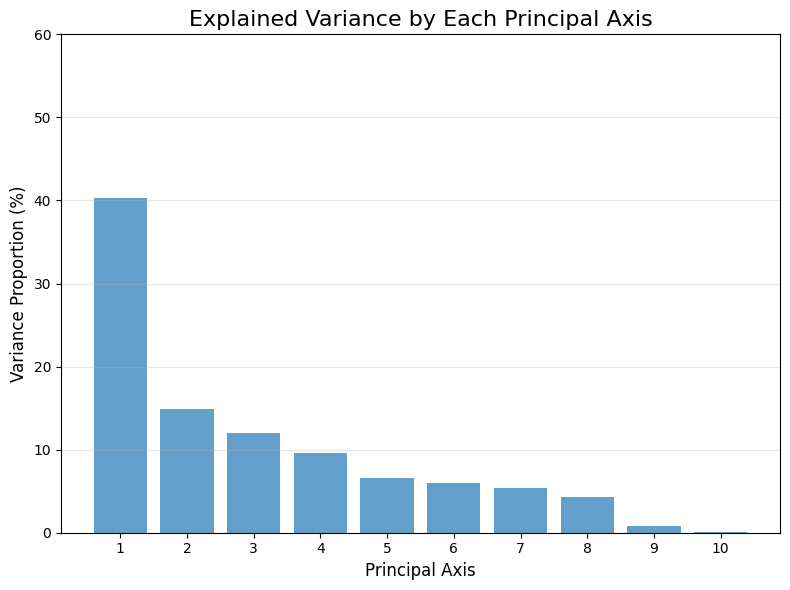

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(range(1, r_m+1), 100 * var_ratio, alpha=0.7)
ax.set_xlabel('Principal Axis', fontsize=12)
ax.set_ylabel('Variance Proportion (%)', fontsize=12)
ax.set_title('Explained Variance by Each Principal Axis', fontsize=16)
ax.set_xticks(range(1, r_m+1))
ax.set_ylim(0, 60)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

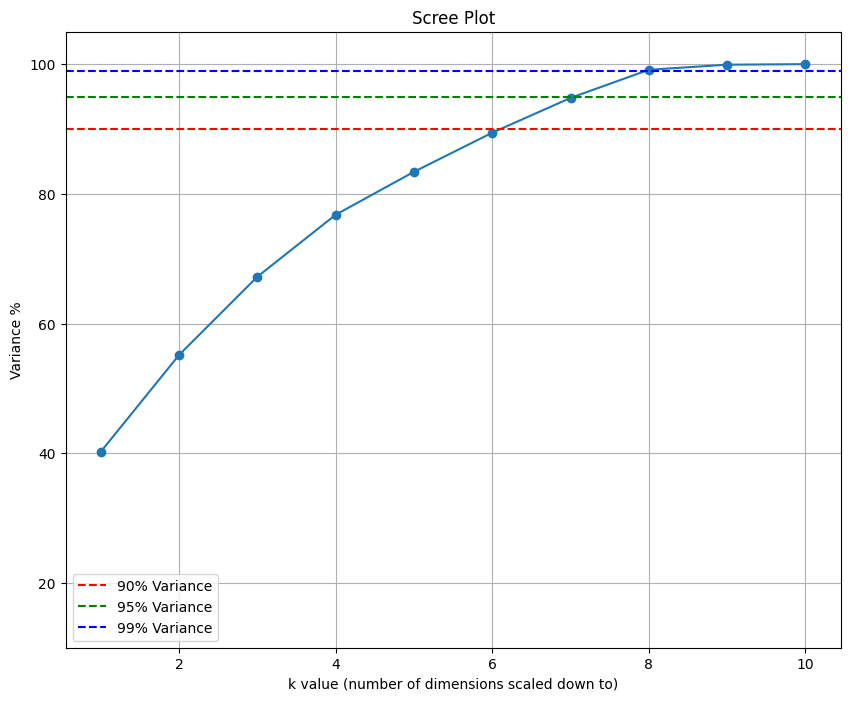

In [ ]:

plt.figure(figsize=(10,8))
plt.plot(range(1, len(percent_variances)+1), percent_variances*100, marker='o')
plt.axhline(90, color='r', linestyle='--', label='90% Variance')
plt.axhline(95, color='g', linestyle='--', label='95% Variance')
plt.axhline(99, color='b', linestyle='--', label='99% Variance')
plt.xlabel('k value (number of dimensions scaled down to)')
plt.ylabel('Variance %')
plt.title('Scree Plot')
plt.ylim(10, 105)
plt.legend()
plt.grid(True)
plt.show()


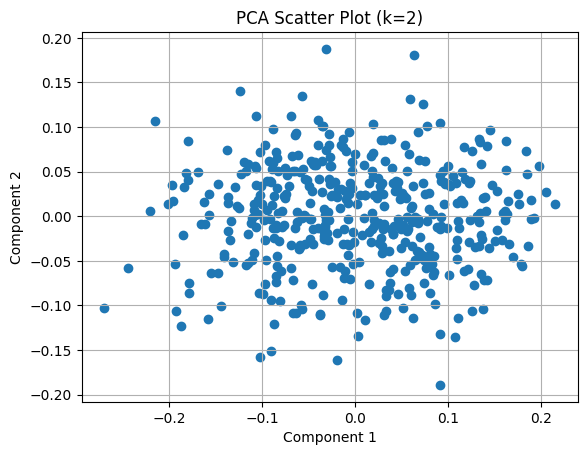

In [ ]:
projected_X, variances, k_components, last = pca_via_svd(X, 2)

plt.scatter(projected_X[:, 0], projected_X[:, 1])

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PCA Scatter Plot (k=2)")
plt.grid(True)
plt.show()

# Reconstructing the Original Data

In [ ]:
diabetes = datasets.load_diabetes()
X = diabetes.data

chosen_k = 7

m_data, n_features = X.shape
centered_X, mean_vector = center(X)
projected, variances, k_components, VT = pca_via_svd(X, chosen_k)


reconstructed = projected @ k_components
print("\nOriginal data ")
print(centered_X)
print("\nReconstructed data from k =", chosen_k)
print(reconstructed)


relative_error = np.linalg.norm(centered_X - reconstructed, 'fro') / np.linalg.norm(centered_X, 'fro')

print(f"\noriginal dimension:    {n_features}")
print(f"k_value:               {chosen_k}")
print(f"Relative error:        {100*relative_error:.2f}%")



Original data 
[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]

Reconstructed data from k = 7
[[ 0.03761512  0.03471281  0.04792447 ...  0.01036764  0.00145898
  -0.01176916]
 [-0.00194951 -0.04062862 -0.04898757 ... -0.0595162  -0.05920052
  -0.09333578]
 [ 0.084718    0.03292225  0.02876461 ...  0.00535027 -0.01608418
  -0.01925987]
 ...
 [ 0.04209238  0.06102089 -0.00650878 ... -0.01088335 -0.03664193
   0.01150339]
 [-0.0454723  -0.04630417  0.03786588 ...  0.03172148  0.04112648
  -0.02539356]
 [-0.04657211 -0.06951494 -0.09659573 ... -0.056863

In [ ]:
print("Different errors for different k values\nOriginal dimension is 10")
for k_i in range (1, 11):
  projected_temp, _, k_components_temp, _ = pca_via_svd(X, k_i)

  reconstructed_temp = projected_temp @ k_components_temp

  relative_error_temp = np.linalg.norm(centered_X - reconstructed_temp, 'fro') / np.linalg.norm(centered_X, 'fro')
  print(f"\nk_value:         {k_i}")
  print(f"Relative error:  {100*relative_error_temp:.2f}%")


Different errors for different k values
Original dimension is 10

k_value:         1
Relative error:  77.30%

k_value:         2
Relative error:  66.96%

k_value:         3
Relative error:  57.25%

k_value:         4
Relative error:  48.19%

k_value:         5
Relative error:  40.74%

k_value:         6
Relative error:  32.51%

k_value:         7
Relative error:  22.82%

k_value:         8
Relative error:  9.32%

k_value:         9
Relative error:  2.93%

k_value:         10
Relative error:  0.00%


In [ ]:
reconstructed_original_data = reconstructed + mean_vector
print("Original Data:\n")
print(X)
print("\n\nReconstructed Data from k = 7:\n")
print(reconstructed_original_data)

Original Data:

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]


Reconstructed Data from k = 7:

[[ 0.03761512  0.03471281  0.04792447 ...  0.01036764  0.00145898
  -0.01176916]
 [-0.00194951 -0.04062862 -0.04898757 ... -0.0595162  -0.05920052
  -0.09333578]
 [ 0.084718    0.03292225  0.02876461 ...  0.00535027 -0.01608418
  -0.01925987]
 ...
 [ 0.04209238  0.06102089 -0.00650878 ... -0.01088335 -0.03664193
   0.01150339]
 [-0.0454723  -0.04630417  0.03786588 ...  0.03172148  0.04112648
  -0.02539356]
 [-0.04657211 -0.06951494 -0.09659573 ... -0.056

# Checking Mean Squared Reconstructed Error
computing mean squared reconstruction error per observation for several values of k and comparing to the theoretical variance (which is the sum of the eigenvalues from k onwards)

In [ ]:
def getting_msre(X, k):
  proj, _, components, _ = pca_via_svd(X, k)
  m_data, n_features = X.shape
  centered_X, mean_vector = center(X)

  X_reconstructed = proj @ components + mean_vector

  #this should be the actual mean squared error per observation
  msre = np.mean(np.sum((X - X_reconstructed)**2, axis=1))

  return msre

_, eigenvals, _ = pca_via_covariance(X, 10)

for i in range (1, 10):
  msre = getting_msre(X, i)
  theoretical_error = np.sum(eigenvals[i:])

  close = ((msre - theoretical_error) / theoretical_error) < 0.01
  print(f"Is the MSRE equal to the theoretical for k = {i}: {close}")

Is the MSRE equal to the theoretical for k = 1: True
Is the MSRE equal to the theoretical for k = 2: True
Is the MSRE equal to the theoretical for k = 3: True
Is the MSRE equal to the theoretical for k = 4: True
Is the MSRE equal to the theoretical for k = 5: True
Is the MSRE equal to the theoretical for k = 6: True
Is the MSRE equal to the theoretical for k = 7: True
Is the MSRE equal to the theoretical for k = 8: True
Is the MSRE equal to the theoretical for k = 9: True


# Comparing PCA via SVD and Covariance
If the methods achieve the same result, the outputted matrix will have all True

In [ ]:
diabetes = datasets.load_diabetes()
X = diabetes.data

chosen_k = 10

m_data, n_features = X.shape
centered_X, mean_vector = center(X)

projected_via_svd, _, k_components_svd, _ = pca_via_svd(X, chosen_k)
projected_via_covariance, _, k_components_covariance = pca_via_covariance(X, chosen_k)

print(f"Are the projections the same: \n{np.isclose(projected_via_svd, projected_via_covariance)}")
print(f"\n\nAre all the components the same: \n{np.isclose(k_components_svd, k_components_covariance)}")


Are the projections the same: 
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


Are all the components the same: 
[[ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]]


# Orthonormality of Principal Components
Verifying that principal components are orthonormal and that
projecting onto them produces an orthogonal basis

In [ ]:
def has_orthonormal_columns(A):
  #checking if (A^T)A = I
  ATA = A.T @ A
  Identity = np.eye(A.shape[1])
  return np.allclose(ATA, Identity)

def has_orthogonal_columns(A):
  #checking if (A^T)A is diagonal
  ATA = A.T @ A
  return np.allclose(ATA, np.diag(np.diag(ATA)))

projection_to_check, _, k_components_to_check, _ = pca_via_svd(X, 10)

print(f"Are the principal components orthonormal: {has_orthonormal_columns(k_components_to_check)}")
print(f"Is the projected basis orthogonal: {has_orthogonal_columns(projection_to_check)}")



Are the principal components orthonormal: True
Is the projected basis orthogonal: True
